In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import numpy as np
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.kernel_approximation import RBFSampler
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler
import pyarrow 
import pyarrow.parquet
from matplotlib import pyplot
import time

In [4]:
df = pd.read_csv("results.csv")

In [5]:
summary = df.groupby(["drift_type", "window"]).agg(
    tp_regular    = ("tp_regular",    "mean"),
    fp_regular    = ("fp_regular",    "mean"),
    fn_regular    = ("fn_regular",    "mean"),
    delay_regular = ("delay_regular", "mean"),

    tp_irregular    = ("tp_irregular",    "mean"),
    fp_irregular    = ("fp_irregular",    "mean"),
    fn_irregular    = ("fn_irregular",    "mean"),
    delay_irregular = ("delay_irregular", "mean"),
).round(2)

print(summary.to_string())

                   tp_regular  fp_regular  fn_regular  delay_regular  tp_irregular  fp_irregular  fn_irregular  delay_irregular
drift_type window                                                                                                              
1          168           1.00        2.90        0.00        1288.80          1.00         12.80          0.00           857.00
           720           0.30        0.90        0.70        6922.33          0.90          4.25          0.10          1749.33
           2160          0.80        4.93        0.20        3213.62          0.67          7.17          0.33          1631.45
2          168           1.00        2.70        0.00        7269.60          1.00         12.50          0.00          4464.20
           720           0.25        0.60        0.75       20390.60          0.90          1.75          0.10          9213.33
           2160          0.77        0.83        0.23        9746.22          0.60          2.77        

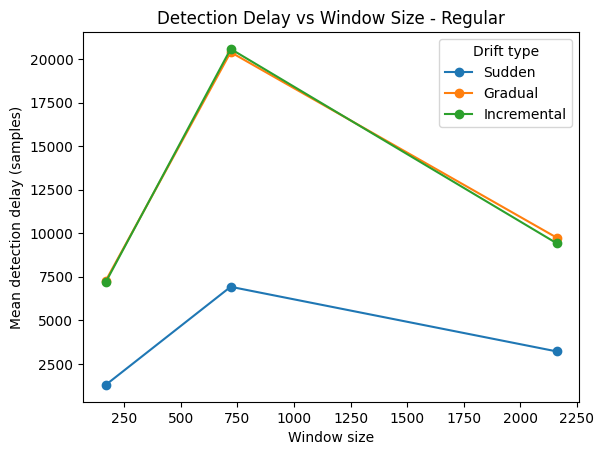

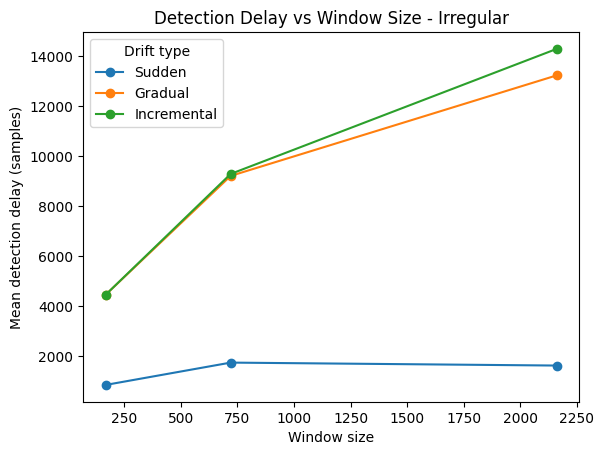

In [14]:
drift_labels = {1: "Sudden", 2: "Gradual", 3: "Incremental"}

for dataset, prefix in [("Regular", "regular"), ("Irregular", "irregular")]:
    for drift_type, group in summary.groupby("drift_type"):
        windows = group.index.get_level_values("window")
        plt.plot(windows, group[f"delay_{prefix}"], marker="o", label=drift_labels[drift_type])

    plt.title(f"Detection Delay vs Window Size - {dataset}")
    plt.xlabel("Window size")
    plt.ylabel("Mean detection delay (samples)")
    plt.legend(title="Drift type")
    plt.show()

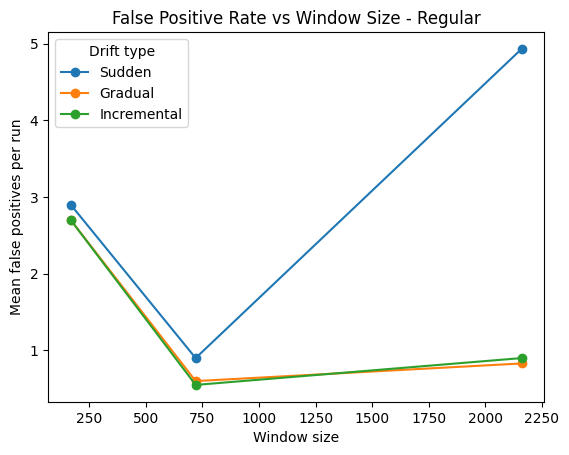

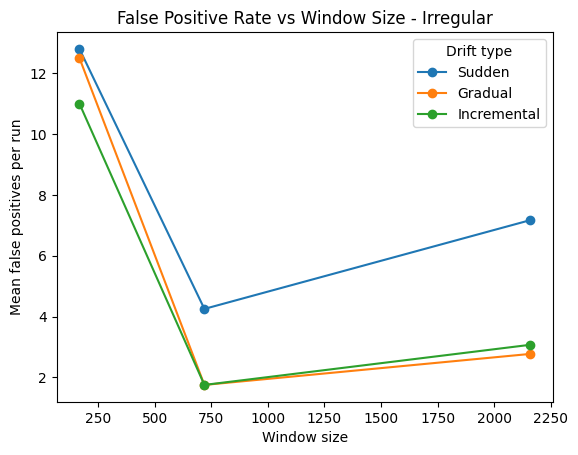

In [13]:
for dataset, prefix in [("Regular", "regular"), ("Irregular", "irregular")]:
    for drift_type, group in summary.groupby("drift_type"):
        windows = group.index.get_level_values("window")
        plt.plot(windows, group[f"fp_{prefix}"], marker="o", label=drift_labels[drift_type])

    plt.title(f"False Positive Rate vs Window Size - {dataset}")
    plt.xlabel("Window size")
    plt.ylabel("Mean false positives per run")
    plt.legend(title="Drift type")
    plt.show()

In [16]:
summary_step = df.groupby(["drift_type", "step"]).agg(
    tp_regular      = ("tp_regular",    "mean"),
    fp_regular      = ("fp_regular",    "mean"),
    fn_regular      = ("fn_regular",    "mean"),
    delay_regular   = ("delay_regular", "mean"),
    tp_irregular    = ("tp_irregular",    "mean"),
    fp_irregular    = ("fp_irregular",    "mean"),
    fn_irregular    = ("fn_irregular",    "mean"),
    delay_irregular = ("delay_irregular", "mean"),
).round(2)

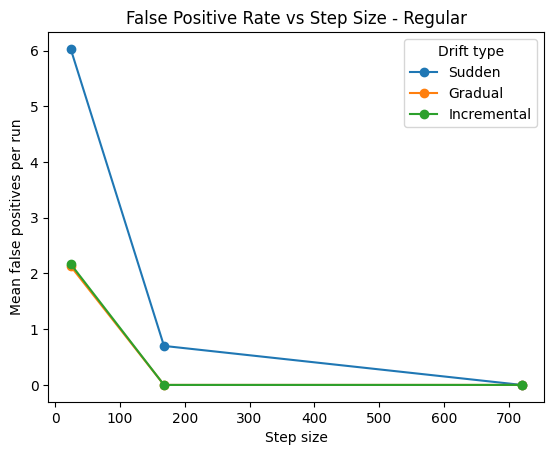

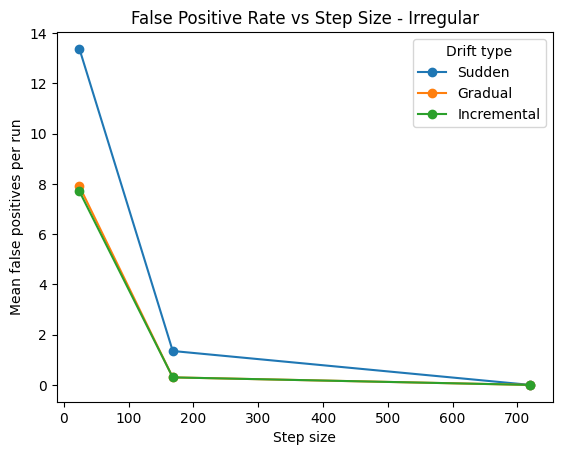

In [17]:
for dataset, prefix in [("Regular", "regular"), ("Irregular", "irregular")]:
    for drift_type, group in summary_step.groupby("drift_type"):
        steps = group.index.get_level_values("step")
        plt.plot(steps, group[f"fp_{prefix}"], marker="o", label=drift_labels[drift_type])

    plt.title(f"False Positive Rate vs Step Size - {dataset}")
    plt.xlabel("Step size")
    plt.ylabel("Mean false positives per run")
    plt.legend(title="Drift type")
    plt.show()